# Exercício 1

Todo número real $x \in [0,1]$ pode ser representado, ou aproximado, por meio de uma **decomposição binária**. Nessa representação, utilizamos apenas os dígitos 0 e 1.

Considerando os primeiros $D$ dígitos binários, podemos escrever

$$
x = \frac{b_1}{2} + \frac{b_2}{2^2} + \frac{b_3}{2^3} + \cdots + \frac{b_D}{2^D},
$$

em que cada $b_i \in \{0,1\}$.

Por exemplo, o número binário $0.101_2$ corresponde, na base decimal, a

$$
0.101_2
=
1\cdot\frac{1}{2}
+
0\cdot\frac{1}{2^2}
+
1\cdot\frac{1}{2^3}
=
0.625.
$$

Assim, ao gerar aleatoriamente uma sequência de zeros e uns, podemos utilizá-la como os dígitos de uma expansão binária e, dessa forma, construir números aleatórios no intervalo $[0,1]$.


Utilizando a função `np.random.choice`, gere uma sequência de tamanho $D$ composta por dígitos 0 ou 1.

1. Utilizando essa sequência e um laço `for`, construa um número aleatório entre 0 e 1 a partir de sua decomposição binária, conforme descrito acima.

2. Utilizando a função `np.arange`, repita o procedimento do item anterior **sem utilizar um laço `for`**. Faça o cálculo por meio de operações vetorizadas, utilizando a multiplicação termo a termo entre os dígitos binários e as respectivas potências de $1/2$.

3. Utilizando o procedimento vetorizado desenvolvido no item 2, gere uma amostra de tamanho $N$ de números aleatórios no intervalo $[0,1]$. Em seguida, gere outra amostra de mesmo tamanho utilizando a função `np.random.uniform`. Compare as distribuições das duas amostras por meio de histogramas e discuta se o procedimento baseado na decomposição binária produz resultados compatíveis com uma distribuição uniforme.

4. Repita o passo 3 várias vezes com diferentes valores de $D$ e comente qual o efeito de aumentar ou diminuir $D$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Exercicio 1.1
D = 100000
total = 0
v = np.random.choice(2, size=D)
for i in range (0, D):
  total = total + v[i]*((0.5)**(1+i))


total

np.float64(0.2731996752115644)

In [2]:
#Exercicio 1.2

np.arange(1,D)
tot = 0
vx = np.arange(1,D)/2*np.arange(1,D)

tot = sum(v[np.arange(1,D)]*((0.5)**(np.arange(1,D))))


print(tot)

0.5463993504231288


(array([ 969.,  981., 1021.,  966., 1012., 1063.,  984., 1008.,  981.,
        1015.]),
 array([8.60221855e-06, 9.99594169e-02, 1.99910232e-01, 2.99861046e-01,
        3.99811861e-01, 4.99762676e-01, 5.99713491e-01, 6.99664305e-01,
        7.99615120e-01, 8.99565935e-01, 9.99516749e-01]),
 <BarContainer object of 10 artists>)

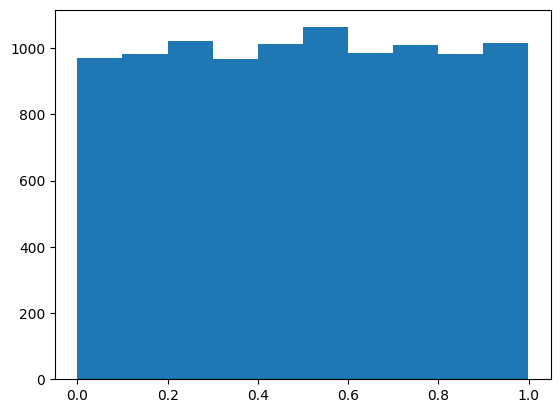

In [3]:
#Exercicio 1.3
amostra_final = []
N = 10000
np.random.seed(0)
for i in range(N):

  x = np.random.choice(2, size=D)
  t = np.sum(((1/2)**np.arange(1,D+1)* x))
  amostra_final.append(t)
plt.hist(amostra_final)

Exercicio 1.4
Quanto maior o D, o gráfico ficará cada vez mais reto

# Exercício 2 — Simulação de variáveis aleatórias a partir da distribuição uniforme

Apesar de o exercício anterior mostrar como podemos gerar variáveis uniformes em $[0,1]$ a partir de lançamentos de moedas, a partir de agora, e ao longo do curso, assumiremos que o único mecanismo de geração de números aleatórios disponível é a geração de variáveis uniformes no intervalo $[0,1]$.

Neste exercício, vamos utilizar variáveis uniformes para simular algumas das variáveis aleatórias discretas vistas em sala.

A ideia fundamental será transformar uma variável

$$
U \sim \text{Uniforme}(0,1)
$$

em outra variável aleatória por meio de uma função apropriada.

Em todos os itens, considere uma amostra de tamanho $N$.

## 1. Gerando a amostra uniforme

Utilizando `np.random.uniform`, gere uma amostra

$$
U_1,\ldots,U_N
$$

de variáveis aleatórias independentes com distribuição uniforme em $[0,1]$.

Essa será a única fonte de aleatoriedade utilizada nos itens seguintes.

In [4]:
N =1000
amostra_uniforme = np.random.uniform(size=N)
print(amostra_uniforme)

[6.23726540e-01 8.39693250e-01 5.86730280e-01 9.58997870e-01
 8.07305242e-01 6.51146358e-01 5.97407480e-01 4.00494713e-01
 8.81353111e-01 9.43596636e-01 4.97490360e-01 5.63957659e-01
 6.62505585e-01 5.44925088e-01 9.69759801e-01 5.48069427e-01
 4.90801921e-01 7.67627337e-01 9.75691009e-01 2.34328387e-01
 9.48649367e-01 6.42482142e-01 3.45490758e-01 6.58912334e-01
 8.60267712e-03 4.14201809e-01 6.98607465e-01 8.13237418e-01
 3.95829791e-01 2.37295442e-01 6.37697683e-01 2.87522422e-01
 4.12589665e-01 5.59855078e-01 5.41491740e-01 6.28796240e-01
 5.96667169e-01 8.07524719e-01 8.11845668e-01 2.79994583e-01
 7.66437980e-01 8.15432844e-01 2.60253093e-01 5.79649533e-01
 3.81537707e-02 9.58319376e-01 6.52227890e-01 3.75705994e-01
 8.69363369e-02 2.26176412e-01 7.08839866e-01 2.05664127e-01
 9.06422465e-01 4.51984464e-02 8.00417827e-01 9.35845550e-01
 4.14791628e-01 6.68642457e-01 7.67328771e-01 9.46127222e-01
 2.30230633e-02 1.37189498e-01 4.26807035e-02 7.09295029e-02
 1.04504539e-01 8.997502

## 2. Variável Bernoulli

Considere uma variável aleatória Bernoulli com parâmetro $p$, isto é,

$$
P(X=1)=p
\qquad \text{e} \qquad
P(X=0)=1-p.
$$

Utilizando a amostra uniforme gerada no item anterior:

1. Gere uma amostra Bernoulli utilizando um `for` e uma estrutura `if/else`.

2. Crie uma função `f` que transforme valores uniformes em valores `0` ou `1` de acordo com o parâmetro $p$. Em seguida, aplique diretamente essa função à amostra uniforme, isto é, `f(amostra)`.

3. Calcule a média e a variância da amostra Bernoulli obtida e compare-as com os valores teóricos

$$
\mathbb{E}[X]=p
\qquad \text{e} \qquad
\operatorname{Var}(X)=p(1-p).
$$

In [5]:
N = 1000
amostra_uniforme = np.random.uniform(size=N)
#Exercicio 2.2.1
p = 0.7

amostra_final = []

for u in amostra_uniforme:
  if u < p:
    amostra_final.append(1)
  else:
    amostra_final.append(0)

#Exercicio 2.2.2
def bernoulli(p):
  for i in amostra_uniforme:
    uni = np.random.uniform()
    if u<p:
      x.append(1)
    else:
      x.append(0)
  return x

#Exercicio 2.2.3
E = sum(amostra_final)/N
Var = E*(1 - E)
print(E)
print(Var)

0.715
0.203775


## 3. Lançamento de um dado justo

Considere um dado justo de seis faces, de modo que

$$
P(X=k)=\frac{1}{6}, \qquad k=1,\ldots,6.
$$

Utilizando a amostra uniforme gerada no item 1:

1. Gere uma amostra de lançamentos do dado utilizando um `for` e uma estrutura `if/elif/else`.

2. Crie uma função `f` que transforme valores uniformes em valores de `1` a `6`. Em seguida, aplique diretamente a função à amostra uniforme, isto é, `f(amostra)`.

3. Você consegue encontrar uma forma mais simples de fazer essa transformação, sem utilizar `if/elif/else`? Pense no que acontece ao multiplicar um valor uniforme por 6 e considerar apenas sua parte inteira.

4. Calcule a frequência relativa de cada face e compare-a com o valor teórico $1/6$.

5. Calcule a média e a variância da amostra e compare-as com os valores teóricos: $\mathbb{E}[X], \operatorname{Var}(X).$ Você pode calcular usando a fórmula $\operatorname{Var}(X) = \mathbb{E}[X^2] - \mathbb{E}[X]^2$.

6. Repita o procedimento anterior para um dado viciado com probabilidades

$$
P(X=1)=0.05,\quad
P(X=2)=0.10,\quad
P(X=3)=0.15,
$$

$$
P(X=4)=0.20,\quad
P(X=5)=0.20,\quad
P(X=6)=0.30.
$$

Construa uma função `f` que transforme a amostra uniforme em lançamentos desse dado. Compare as frequências relativas obtidas com as probabilidades teóricas acima e compare também a média e a variância amostrais com os valores teóricos.


In [6]:
N = 1000
amostra_uniforme = np.random.uniform(size=N)
#Exercicio 2.3.1
amostra = []
for u in amostra_uniforme:
  if u < 1/6 :
    amostra.append(1)
  elif u < 2/6 :
    amostra.append(2)
  elif u < 3/6 :
    amostra.append(3)
  elif u < 4/6 :
    amostra.append(4)
  elif u < 5/6 :
    amostra.append(5)
  else:
    amostra.append(6)

#Exercicio 2.3.2
def dado(amostras):
  amostra = []
  relativa = [0, 0, 0, 0, 0, 0]
  for u in amostras:
    if u < 1/6 :
      amostra.append(1)
      relativa[0] += 1
    elif u < 2/6 :
      amostra.append(2)
      relativa[1] += 1
    elif u < 3/6 :
      amostra.append(3)
      relativa[2] += 1
    elif u < 4/6 :
      amostra.append(4)
      relativa[3] += 1
    elif u < 5/6 :
      amostra.append(5)
      relativa[4] += 1
    else:
      amostra.append(6)
      relativa[5] += 1
  for i in range(len(relativa)):
    relativa[i] /= N
  return amostra, relativa
dado(amostra_uniforme)
#Exercicio 2.3.3
amostra = []
teiro = np.ceil(amostra_uniforme*6)
amostra.append(teiro)

#Exercicio 2.3.4
a = dado(amostra_uniforme)
comparar = []
for i in range(0, 6):
  comparacao = (a[1][i]/(1/6))
  comparar.append(comparacao)


print(a[0])
print(a[1])
#Exercicio 2.3.5
E_teorico = 0
Var_teorico = 0
E2_teorico = 0
for i in range(1, 7):
  E_teorico += i/6
  E2_teorico += (i**2)/6
E_amostral = np.mean(a[0])
Var_teorico += E2_teorico - E_teorico**2
Var_amostral = np.var(a[0])
CompE = E_amostral/E_teorico
CompVar = Var_amostral/Var_teorico

#Exercicio 2.3.6
def viciado(amostras):
  amostra = []
  relativa = [0, 0, 0, 0, 0, 0]
  for u in amostras:
    if u < 0.05:
      amostra.append(1)
      relativa[0] += 1 #Estava pensando em outro jeito de resolver, mas deixei as relativas mesmo assim
    elif u < 0.15:
      amostra.append(2)
      relativa[1] += 1
    elif u < 0.30:
      amostra.append(3)
      relativa[2] += 1
    elif u < 0.5:
      amostra.append(4)
      relativa[3] += 1
    elif u < 0.7:
      amostra.append(5)
      relativa[4] += 1
    else:
      amostra.append(6)
      relativa[5] += 1
  return amostra, relativa

a = viciado(amostra_uniforme)
Ea_viciado = np.mean(a[0])
Vara_viciado = np.var(a[0])
Et_viciado = 0.05*1 + 0.1*2 + 0.15*3 + 0.2*4 + 0.2*5 + 0.3*6
Vart_viciado = 0.05*(1**2) + 0.1*(2**2) + 0.15*(3**2) + 0.2*(4**2) + 0.2*(5**2) + 0.3*(6**2) - Et_viciado**2
CompE_viciado = Ea_viciado/Et_viciado
CompVar_viciado = Vara_viciado/Vart_viciado


[4, 1, 5, 2, 4, 6, 1, 5, 3, 5, 3, 6, 1, 4, 5, 1, 5, 5, 1, 6, 4, 6, 6, 4, 4, 1, 2, 5, 4, 1, 1, 1, 5, 6, 6, 2, 1, 6, 3, 6, 6, 3, 6, 3, 6, 2, 3, 1, 2, 6, 5, 4, 5, 1, 4, 3, 4, 5, 1, 2, 4, 2, 5, 4, 5, 4, 3, 5, 6, 6, 4, 6, 5, 1, 3, 6, 1, 1, 4, 4, 2, 5, 3, 3, 5, 1, 6, 3, 5, 1, 6, 6, 3, 6, 4, 5, 6, 3, 5, 5, 2, 6, 6, 1, 5, 1, 5, 1, 2, 5, 2, 4, 5, 3, 5, 4, 3, 3, 3, 5, 3, 6, 1, 2, 1, 2, 6, 3, 3, 4, 4, 2, 3, 1, 5, 3, 5, 1, 1, 6, 4, 6, 4, 1, 3, 3, 6, 1, 4, 2, 1, 3, 2, 1, 1, 4, 3, 2, 5, 6, 4, 5, 1, 4, 1, 6, 6, 3, 5, 5, 6, 4, 6, 1, 5, 3, 5, 3, 4, 4, 1, 6, 4, 4, 4, 5, 5, 4, 4, 1, 5, 6, 5, 5, 6, 5, 3, 1, 3, 1, 6, 5, 1, 4, 6, 2, 6, 4, 2, 6, 1, 4, 1, 6, 2, 5, 5, 2, 4, 2, 4, 4, 6, 1, 5, 2, 1, 2, 6, 1, 3, 1, 5, 5, 6, 3, 3, 1, 4, 2, 5, 1, 6, 2, 6, 3, 3, 4, 1, 6, 3, 4, 1, 3, 1, 6, 6, 1, 2, 5, 1, 1, 5, 1, 6, 1, 2, 3, 1, 1, 4, 6, 4, 4, 4, 6, 1, 3, 5, 3, 3, 1, 6, 2, 5, 4, 6, 3, 2, 3, 1, 3, 6, 5, 3, 5, 5, 2, 6, 3, 3, 6, 5, 4, 6, 2, 2, 6, 3, 5, 3, 2, 5, 4, 6, 5, 6, 3, 4, 1, 2, 2, 5, 3, 1, 1, 5, 2, 4, 5, 5, 2, 1, 

In [7]:
a = 10
a //= 2
print(a)

5


## 4. Distribuição Binomial

Podemos interpretar uma variável aleatória binomial pensando em lançamentos de uma moeda. Suponha que lançamos uma moeda $n$ vezes, de forma independente, e que a probabilidade de obter **cara** em cada lançamento seja $p$.

Se contarmos o número total de caras obtidas nesses $n$ lançamentos, esse número segue uma distribuição binomial:

$$
X \sim \mathrm{Binomial}(n,p).
$$

Assim, uma variável binomial nada mais é do que a soma de $n$ variáveis Bernoulli independentes:

$$
X = X_1 + \cdots + X_n,
\qquad
X_i \sim \mathrm{Bernoulli}(p),
$$

onde $X_i=1$ representa uma cara e $X_i=0$ representa uma coroa.

1. Utilizando o procedimento desenvolvido anteriormente para gerar variáveis Bernoulli, gere uma amostra de tamanho $N$ de variáveis com distribuição $\mathrm{Binomial}(n,p)$.

2. Calcule a média e a variância da amostra e compare-as com os valores teóricos

$$
\mathbb{E}[X]=np
\qquad \text{e} \qquad
\operatorname{Var}(X)=np(1-p).
$$

3. Gere uma segunda amostra de tamanho $N$ utilizando `np.random.binomial` com os mesmos parâmetros $n$ e $p$. Compare as duas amostras por meio de histogramas.


[np.int64(517), np.int64(481), np.int64(499), np.int64(533), np.int64(511), np.int64(507), np.int64(508), np.int64(502), np.int64(506), np.int64(500), np.int64(529), np.int64(508), np.int64(497), np.int64(498), np.int64(536), np.int64(531), np.int64(501), np.int64(488), np.int64(497), np.int64(480), np.int64(479), np.int64(478), np.int64(509), np.int64(525), np.int64(477), np.int64(510), np.int64(482), np.int64(494), np.int64(499), np.int64(477), np.int64(526), np.int64(505), np.int64(509), np.int64(515), np.int64(497), np.int64(512), np.int64(488), np.int64(522), np.int64(488), np.int64(487), np.int64(481), np.int64(492), np.int64(523), np.int64(492), np.int64(494), np.int64(498), np.int64(515), np.int64(504), np.int64(491), np.int64(480), np.int64(481), np.int64(487), np.int64(506), np.int64(496), np.int64(507), np.int64(513), np.int64(486), np.int64(507), np.int64(491), np.int64(498), np.int64(516), np.int64(507), np.int64(536), np.int64(489), np.int64(496), np.int64(481), np.int64(

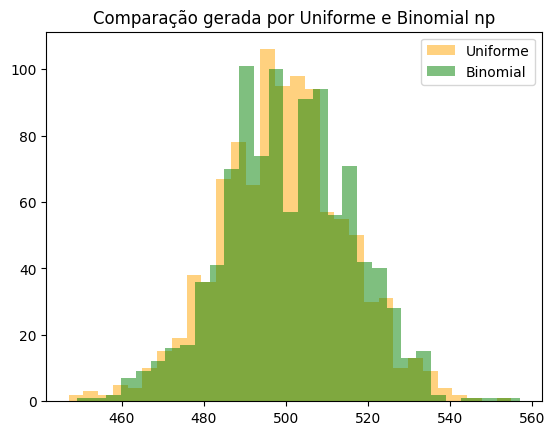

In [29]:
amostra = []
np.random.seed(0)
N = 1000
p = .5
#Exercicio 2.4.1
for i in range(N):
  u = np.random.uniform(size = N)
  bin = np.sum(u < p)
  amostra.append(bin)

print(amostra)
#Exercicio 2.4.2
freq_relativa = np.sum(amostra)/N
Variancia = (np.sum(amostra)/N)*(1-p)

print(freq_relativa)
print(Variancia)

#Exercicio 2.4.3
amostra2 = np.random.binomial(N, p, size=N)
plt.hist(amostra, bins=30, alpha=.5, label= 'Uniforme', color = 'orange')
plt.hist(amostra2, bins=30, alpha= .5, label= 'Binomial', color = 'green')

plt.legend()
plt.title('Comparação gerada por Uniforme e Binomial np')
plt.show()

## 5. Distribuição Multinomial

A distribuição multinomial é uma generalização da distribuição binomial.

Na distribuição binomial, realizamos $n$ lançamentos de uma moeda e contamos quantas vezes ocorreu um dos dois resultados possíveis. Na distribuição multinomial, fazemos a mesma ideia, mas com $k$ resultados possíveis.

Por exemplo, considere um dado de $k$ lados, em que a face $i$ aparece com probabilidade $p_i$, com

$$
p_1+\cdots+p_k=1.
$$

Após $n$ lançamentos, definimos

$$
X=(X_1,\ldots,X_k),
$$

onde $X_i$ representa o número de vezes que a face $i$ apareceu. Nesse caso,

$$
X \sim \mathrm{Multinomial}(n,p_1,\ldots,p_k),
$$

e

$$
X_1+\cdots+X_k=n.
$$

Considere agora um dado de **4 lados** com probabilidades

$$
P(X=1)=0.10,\qquad
P(X=2)=0.20,\qquad
P(X=3)=0.30,\qquad
P(X=4)=0.40.
$$

1. Utilizando o procedimento desenvolvido anteriormente, realize $n$ lançamentos desse dado e conte quantas vezes cada uma das quatro faces apareceu.

2. Repita esse experimento $N$ vezes, gerando uma amostra de tamanho $N$ de vetores com distribuição multinomial.

3. Para cada face $i$, calcule a média amostral de $X_i$ e compare-a com o valor teórico

$$
\mathbb{E}[X_i]=np_i.
$$

4. Gere uma segunda amostra utilizando `np.random.multinomial` com os mesmos parâmetros e compare os resultados obtidos pelos dois métodos.

5. Verifique que, em cada realização, a soma das contagens das $k$ faces é igual a $n$.

6. Para cada face $i$, calcule a variância amostral de $X_i$ e compare-a com

$$
\operatorname{Var}(X_i)=np_i(1-p_i).
$$

7. Escolha duas faces distintas e calcule a covariância amostral entre suas contagens. Compare-a com

$$
\operatorname{Cov}(X_i,X_j)=-np_ip_j.
$$

Interprete o sinal negativo dessa covariância.

In [79]:
N = 1000
p1 = .1
p2 = .2
p3 = .3
p4 = .4
amostra = []
amostrinha = []
#Exercicio 2.5.1
np.random.seed(0)
for i in range(0, N):
  n1 = 0 ; n2 = 0 ; n3 = 0 ; n4 = 0
  for j in range(0, N):
    u = np.random.uniform()
    if (u < p1):
      n1 += 1
    elif (u < .3):
      n2 += 1
    elif (u < .6):
      n3 += 1
    else:
      n4 += 1
    amostrinha = [n1, n2, n3 , n4]
  amostra.append(amostrinha)
amostra
#Exercicio 2.5.2
#Adicionei as listas amostras e amostrinhas, aonde a amostrinha é uma lista de com os valores de uma multinomial e a amostra é uma lista aonde cada elemento é uma amostrinha

#Exercicio 2.5.3
#Criando as esperanças teoricas
E1 = N*p1
E2 = N*p2
E3 = N*p3
E4 = N*p4
#Comparando com o valor amostral
CompE1 = n1/E1
CompE2 = n2/E2
CompE3 = n3/E3
CompE4 = n4/E4

#Exercicio 2.5.4
p = [p1, p2, p3, p4]
mult = np.random.multinomial(N, p)
compsmults = []
for l in range(0, 4):
  CompMults = amostrinha[l]/mult[l]
  compsmults.append(CompMults)
print(compsmults)

#Exercicio 2.5.5
soma = sum(amostrinha)
compsoma = soma/N
print(compsoma)
#Exercicio 2.5.6
#Criei uma a uma as variancias
Var1 = (N*p1)*(1-p1)
Var2 = N*p2*(1-p2)
Var3 = N*p3*(1-p3)
Var4 = N*p4*(1-p4)
VarA1 = 0 ; VarA2 = 0; VarA3 =0 ; VarA4 = 0
for amostrinha in amostra:
  VarA1 += ((amostrinha[0]-E1)**2)/N
  VarA2 += ((amostrinha[1]-E2)**2)/N
  VarA3 += ((amostrinha[2]-E3)**2)/N
  VarA4 += ((amostrinha[3]-E4)**2)/N
CompVar1 = VarA1/Var1
CompVar2 = VarA2/Var2
CompVar3 = VarA3/Var3
CompVar4 = VarA4/Var4

print(CompVar1)
print(CompVar2)
print(CompVar3)
print(CompVar4)
#Exercicio 2.5.7
CovA12 = 0
for amostrinha in amostra:
  CovA12 += ((amostrinha[0]-E1)*(amostrinha[1]-E2))/(N-1)
Cov12 = -1*(N*p1*p2)
CompCov12 = CovA12/Cov12

print(CompCov12)


[np.float64(0.963302752293578), np.float64(0.909952606635071), np.float64(1.0568561872909699), np.float64(1.015748031496063)]
1.0
1.012388888888891
0.9688750000000018
0.9715190476190445
0.9362000000000003
0.9516516516516503
